In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

sns.set(style='whitegrid')
df = pd.read_csv('titanic.csv')
df.shape

(891, 12)

In [4]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['HasCabin'] = df['Cabin'].notnull().astype(int)
df.drop('Cabin', axis=1, inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


In [5]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
def map_title(t):
    if t in ['Mr', 'Miss', 'Mrs', 'Master']:
        return t
    elif t in ['Mlle', 'Ms']:
        return 'Miss'
    elif t in ['Mme']:
        return 'Mrs'
    else:
        return 'Rare'
df['Title'] = df['Title'].apply(map_title)
print(df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


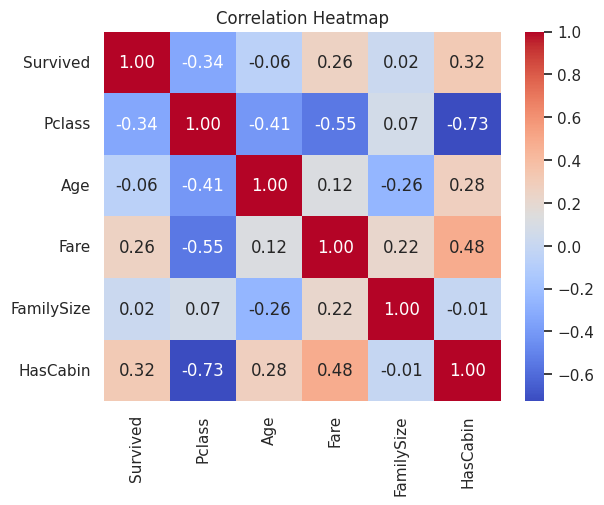

In [6]:
sns.heatmap(df[['Survived','Pclass','Age','Fare','FamilySize','HasCabin']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df_model = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','HasCabin','FamilySize','IsAlone'] + \
           [c for c in df_model.columns if c.startswith('Embarked_') or c.startswith('Title_')]

X = df_model[features]; y = df_model['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

cv_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=5)
print('Mean CV accuracy:', cv_scores.mean())
print('Test accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

Mean CV accuracy: 0.8174628188712696
Test accuracy: 0.8379888268156425
Precision: 0.803030303030303
Recall: 0.7681159420289855
F1: 0.7851851851851852
ROC-AUC: 0.8715415019762845
[[97 13]
 [16 53]]


In [8]:
X_cluster = df_model[['Age', 'Fare', 'FamilySize']].values
scaler2 = StandardScaler()
X_cluster_scaled = scaler2.fit_transform(X_cluster)

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    print(f'k={k}: silhouette={silhouette_score(X_cluster_scaled, labels):.4f}')

k=2: silhouette=0.5290
k=3: silhouette=0.4353
k=4: silhouette=0.4302
k=5: silhouette=0.4236
k=6: silhouette=0.4391
k=7: silhouette=0.3846


In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_model['PassengerCluster'] = kmeans.fit_predict(X_cluster_scaled)

profile = df_model.groupby('PassengerCluster').agg(
    Count=('PassengerId', 'count'), Avg_Age=('Age', 'mean'),
    Avg_Fare=('Fare', 'mean'), Avg_FamilySize=('FamilySize', 'mean'),
    Survival_Rate=('Survived', 'mean'), Avg_Pclass=('Pclass', 'mean')).round(2)
print(profile)

                  Count  Avg_Age  Avg_Fare  Avg_FamilySize  Survival_Rate  \
PassengerCluster                                                            
0                   230    45.79     34.33            1.55           0.39   
1                   548    23.59     17.55            1.44           0.37   
2                    75    15.41     40.29            6.08           0.27   
3                    38    34.84    214.62            2.50           0.76   

                  Avg_Pclass  
PassengerCluster              
0                       1.71  
1                       2.59  
2                       2.76  
3                       1.00  
